In [39]:
imgpath = r'/Volumes/home/kuning/Experiment data/260416. BFSERS-ML data collection 3.2/plate 2/260416. BFSERS-ML data collection 3.2_img.db'

In [40]:
import sys
import os

SCRIPT_DIR = os.path.abspath(r'../../iris')
print(f"Script directory: {SCRIPT_DIR}")
EXT_DIR = os.path.abspath(r'../../extensions')
sys.path.insert(0, os.path.dirname(SCRIPT_DIR))
sys.path.insert(0, os.path.dirname(EXT_DIR))

Script directory: /Users/kuning/Documents/GitHub/orm-iris/iris


In [41]:
from dataclasses import dataclass
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from matplotlib.path import Path as MplPath

# Masking parameter dataclasses
from extensions.bf_sersSubstrate_coorGen.masking.fitting import Param_Smoothen_Boundary
from extensions.bf_sersSubstrate_coorGen.masking.basic_image_processing import (
    Params_Centre_Estimation, Params_Edge_Detection,
)

# Masking pipeline functions
from extensions.bf_sersSubstrate_coorGen.masking.image_preprocessing import (
    convert_img2gray_s_channel,
)
from extensions.bf_sersSubstrate_coorGen.masking.basic_image_processing import (
    estimate_centre_blurring, detect_edge_Sobel,
)
from extensions.bf_sersSubstrate_coorGen.masking.fitting import (
    fit_ellipse_ransac, smoothen_boundary,
)

# Local utilities
from extensions.bf_sersSubstrate_coorGen.utils import (
    Ellipse_Polar, Ellipse_Cartesian, generate_mask,
)

In [42]:
# ── Pipeline parameters ────────────────────────────────────────────────────────
# These will eventually live in the extension GUI; defined manually for now.

params_centre_estimation_default = Params_Centre_Estimation(
    sigma      = 50,   # Gaussian blur sigma for blob detection [px]
    percentile = 70,   # Top (100-percentile)% of pixels define the bright blob
)

params_edge_detection_default = Params_Edge_Detection(
    sigma           = 5,     # Gaussian blur before Sobel [px]
    sobel_threshold = 0.2,   # Relative Sobel threshold (0–1)
    r_min           = 100,   # Min search radius from centre [px]
    r_max           = 300,   # Max search radius from centre [px]
    n_bins          = 720,   # Angular bins (720 = 0.5° resolution)
)

params_smoothen_boundary_default = Param_Smoothen_Boundary(
    outlier_threshold_px = 40,  # Outlier rejection vs RANSAC ellipse [px]
    savgol_window        = 11,  # Savitzky-Golay window length
    savgol_polyorder     = 2,   # Savitzky-Golay polynomial order
)

# Scan grid step size
step_size_mm = 0.05   # [mm] → ~50 µm

# Z position for all scan points (stage Z-coordinate, mm)
z_mm = 0.0

# ROI boundary expansion — physical margin added outward in all directions
expansion_mm = 0.1   # [mm] = 100 µm

print(f'Step size: {step_size_mm*1e3:.0f} µm')

Step size: 50 µm


In [43]:
from iris.data.measurement_image import MeaImg_Handler, MeaImg_Hub, MeaImg_Unit, ImgMea_Cal, ImgMea_Cal_Hub
from iris.data.measurement_coordinates import List_MeaCoor_Hub, MeaCoor_mm

Stitched image: 828×815 px
Stage origin (pixel 0,0): (19.187394032643212, -92.02645905903162) mm
Stage extent (pixel w,h): (24.289216885520233, -97.03254927384879) mm


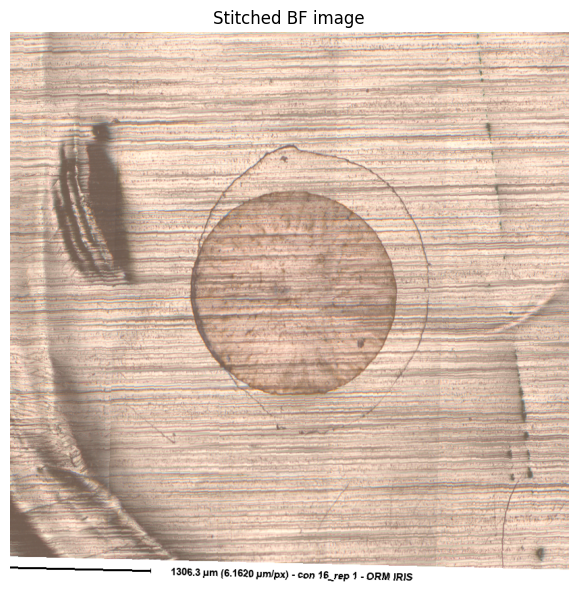

In [44]:
import matplotlib

%matplotlib inline

img_hub = MeaImg_Hub()
MeaImg_Handler().load_ImageMeasurementHub_database(loadpath=imgpath, hub=img_hub)

img_unit = img_hub.get_ImageMeasurementUnit(unit_id=img_hub.get_list_ImageUnit_ids()[0])

# get_image_all_stitched returns (PIL.Image, coor_min_mm, coor_max_mm)
# coor_min_mm is the stage coordinate [mm] of pixel (0,0) in the stitched image
# — needed later for pixel → stage coordinate conversion
img_stitched, coor_min_mm, coor_max_mm = img_unit.get_image_all_stitched(low_res=False)
img_cal = img_unit.get_ImageMeasurement_Calibration()

arr = np.array(img_stitched.convert('RGB'))
hc, wc = arr.shape[:2]

print(f'Stitched image: {wc}×{hc} px')
print(f'Stage origin (pixel 0,0): {coor_min_mm} mm')
print(f'Stage extent (pixel w,h): {coor_max_mm} mm')

plt.figure(figsize=(6, 6))
plt.imshow(img_stitched)
plt.title('Stitched BF image')
plt.axis('off')
plt.tight_layout()
plt.show()

---
## Masking pipeline

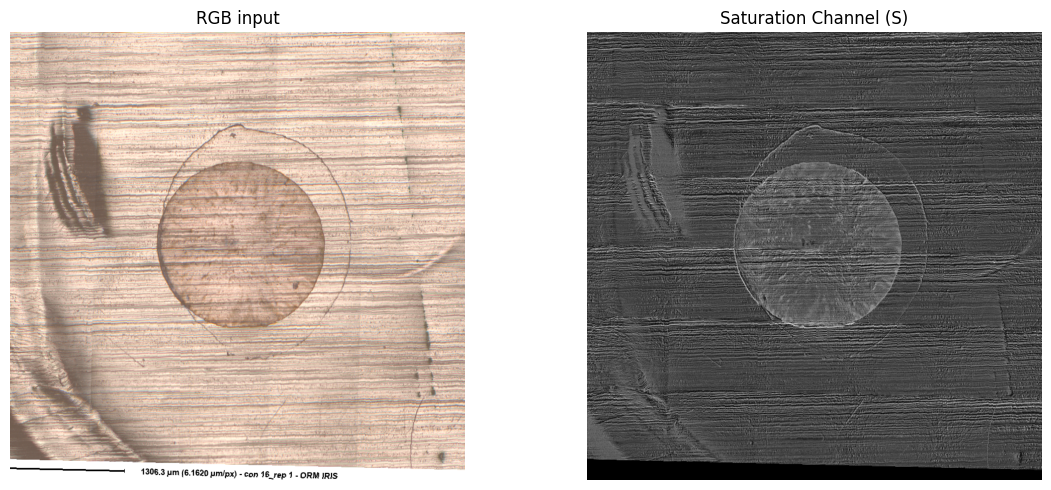

In [45]:
# Step 1 — S-channel extraction
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(arr)
axes[0].set_title('RGB input'); axes[0].axis('off')
S = convert_img2gray_s_channel(arr, axes=axes[1])
plt.tight_layout(); plt.show()

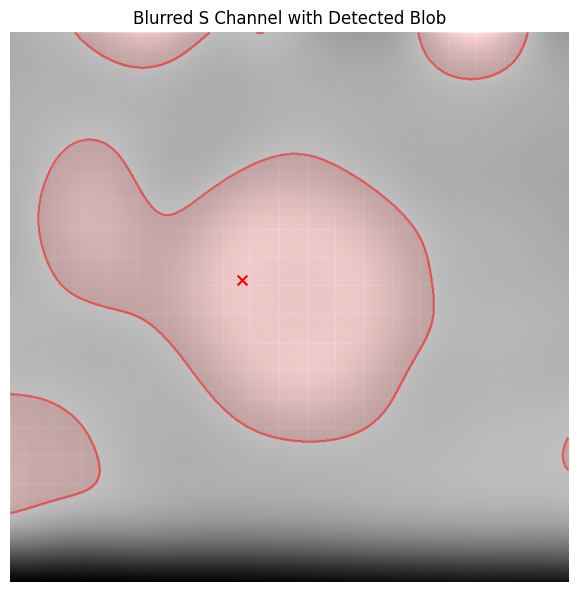

Estimated centre: (343, 367) px


In [46]:
# Step 2 — Centre estimation
fig, ax = plt.subplots(figsize=(6, 6))
cx_est, cy_est = estimate_centre_blurring(
    S, params=params_centre_estimation_default, ax_blob=ax
)
plt.tight_layout(); plt.show()
print(f'Estimated centre: ({cx_est}, {cy_est}) px')

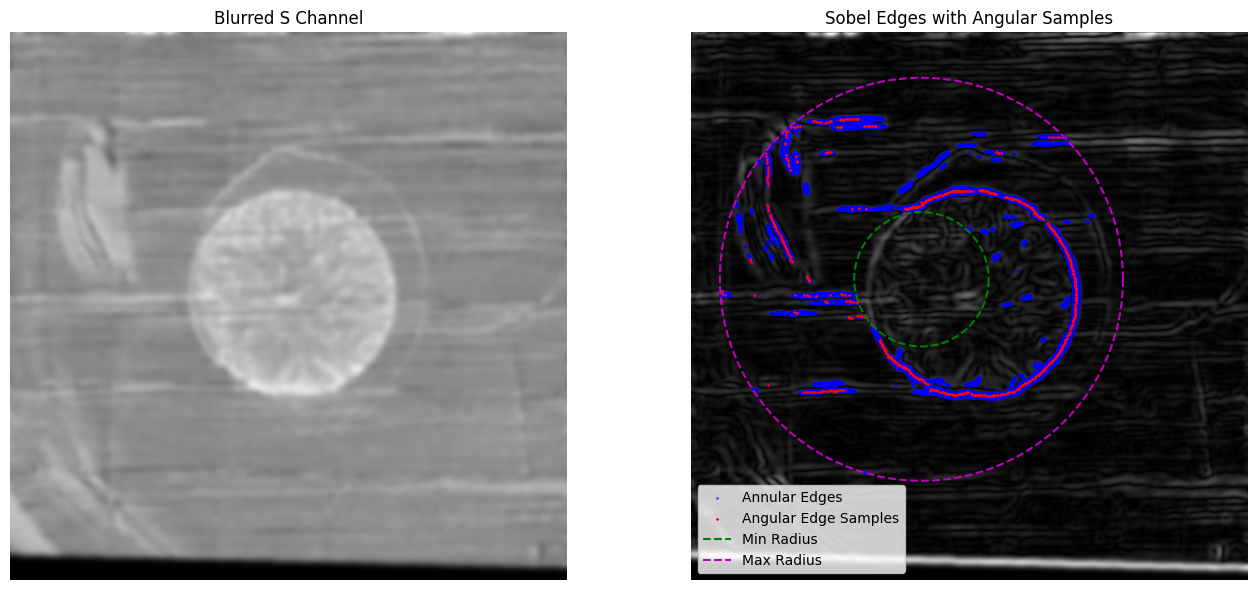

Edge samples: 673 points


In [47]:
# Step 3 — Sobel edge detection
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
ellipse_sobel = detect_edge_Sobel(
    S=S, cx_est=cx_est, cy_est=cy_est,
    params=params_edge_detection_default,
    ax_blur=axes[0], ax_sobel=axes[1],
)
plt.tight_layout(); plt.show()
print(f'Edge samples: {len(ellipse_sobel.x)} points')

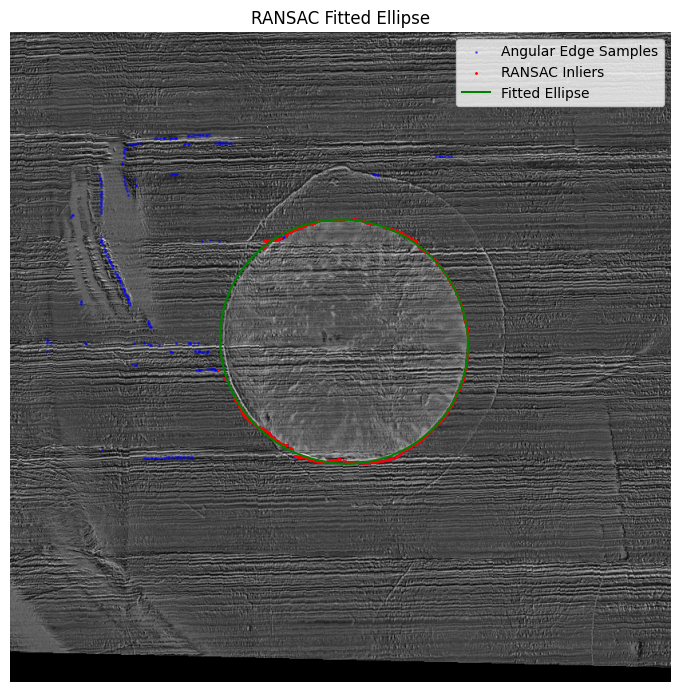

Ellipse: centre=(418.2, 387.8) px | major=312.9 px, minor=304.1 px | circularity=1.000


In [48]:
# Step 4 — RANSAC ellipse fit
fig, ax = plt.subplots(figsize=(7, 7))
ax.imshow(S, cmap='gray')
ellipse_fit = fit_ellipse_ransac(ellipse_sobel, ax_ellipse=ax)
plt.tight_layout(); plt.show()
print(
    f'Ellipse: centre=({ellipse_fit.xc:.1f}, {ellipse_fit.yc:.1f}) px '
    f'| major={ellipse_fit.major_d:.1f} px, minor={ellipse_fit.minor_d:.1f} px '
    f'| circularity={ellipse_fit.circularity:.3f}'
)

In [ ]:
# Step 5 — Boundary smoothing
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[1].imshow(S, cmap='gray')
ellipse_smooth, ellipse_clean = smoothen_boundary(
    ellipse_raw=ellipse_sobel, ellipse_fit=ellipse_fit,
    params=params_smoothen_boundary_default,
    n_bins=params_edge_detection_default.n_bins,
    ax_spherical=axes[0], ax_edges=axes[1],
)
plt.tight_layout(); plt.show()

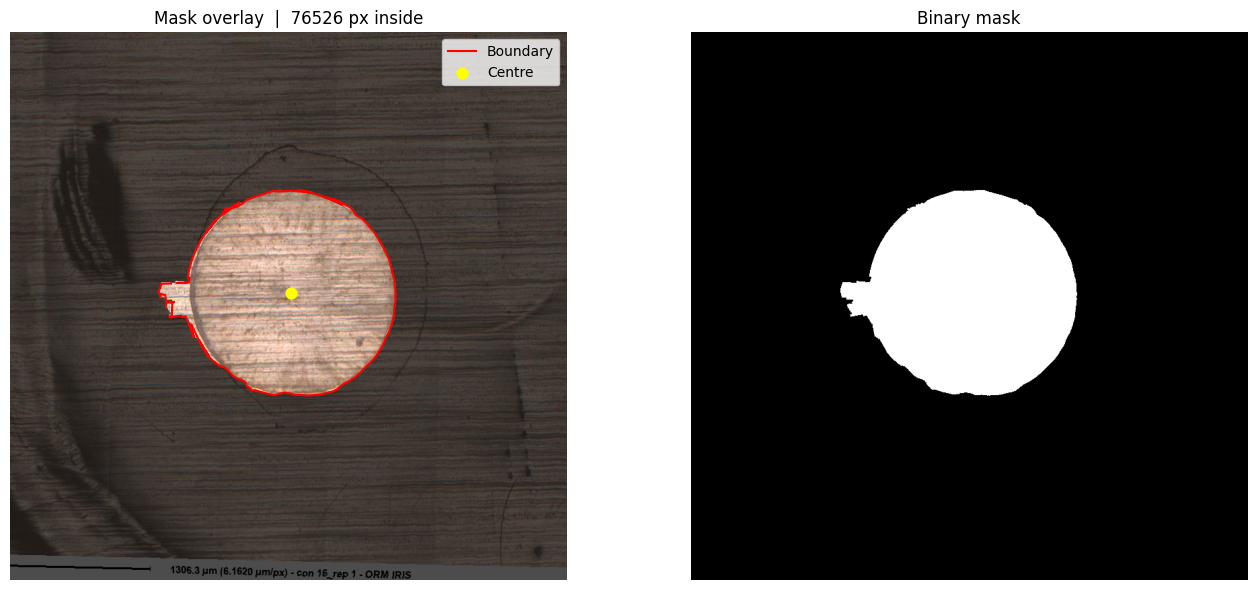

Boundary: 673 pts  |  ROI coverage: 11.3%


In [56]:
# Step 6 — Mask + boundary overlay
# Note: generate_mask uses a pixel-by-pixel loop — fine for notebooks,
# but replace with a vectorised approach for large stitched images.
mask = generate_mask(ellipse=ellipse_smooth, img_height=hc, img_width=wc)

boundary_cart = ellipse_smooth.get_cartesian()
bx, by = boundary_cart.x, boundary_cart.y

overlay = arr.copy()
overlay[~mask] = (overlay[~mask] * 0.3).astype(np.uint8)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].imshow(overlay)
axes[0].plot(bx, by, 'r-', lw=1.5, label='Boundary')
axes[0].scatter(ellipse_fit.xc, ellipse_fit.yc, c='yellow', s=60, zorder=5, label='Centre')
axes[0].set_title(f'Mask overlay  |  {mask.sum()} px inside')
axes[0].legend(); axes[0].axis('off')
axes[1].imshow(mask, cmap='gray')
axes[1].set_title('Binary mask'); axes[1].axis('off')
plt.tight_layout(); plt.show()

print(f'Boundary: {len(bx)} pts  |  ROI coverage: {mask.mean()*100:.1f}%')

---
## Coordinate conversion — image frame → stage frame

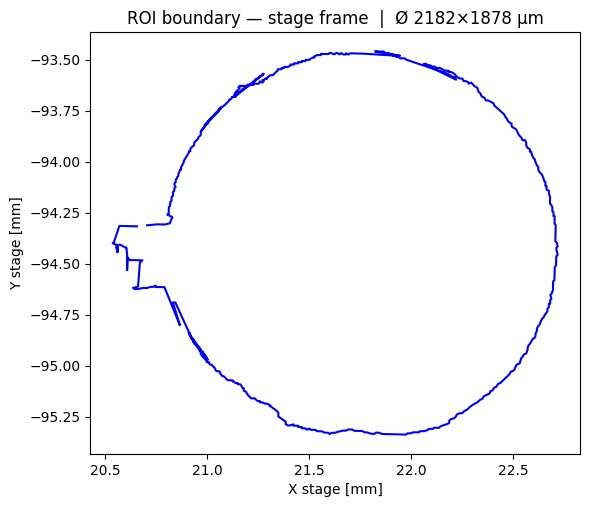

Boundary span: x = 2181.6 µm,  y = 1878.0 µm


In [57]:
# Convert each boundary pixel (in the rotation-corrected stitched image) to
# stage coordinates using the unit's calibration.
#
# convert_imgpt2stg(frame_coor_mm, coor_pixel, correct_rot, low_res)
#   frame_coor_mm  — stage coords of pixel (0,0) of the stitched image
#   correct_rot    — True because get_image_all_stitched applies rotation correction

boundary_stage_mm = np.array([
    img_unit.convert_imgpt2stg(
        frame_coor_mm = coor_min_mm,
        coor_pixel    = (float(px), float(py)),
        correct_rot   = True,
        low_res       = False,
    )
    for px, py in zip(bx, by)
])  # shape (N, 2):  col-0 = x_stage_mm, col-1 = y_stage_mm

x_span = np.ptp(boundary_stage_mm[:, 0])
y_span = np.ptp(boundary_stage_mm[:, 1])

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(boundary_stage_mm[:, 0], boundary_stage_mm[:, 1], 'b-', lw=1.5)
ax.set_aspect('equal')
ax.set_xlabel('X stage [mm]'); ax.set_ylabel('Y stage [mm]')
ax.set_title(f'ROI boundary — stage frame  |  Ø {x_span*1e3:.0f}×{y_span*1e3:.0f} µm')
plt.tight_layout(); plt.show()

print(f'Boundary span: x = {x_span*1e3:.1f} µm,  y = {y_span*1e3:.1f} µm')

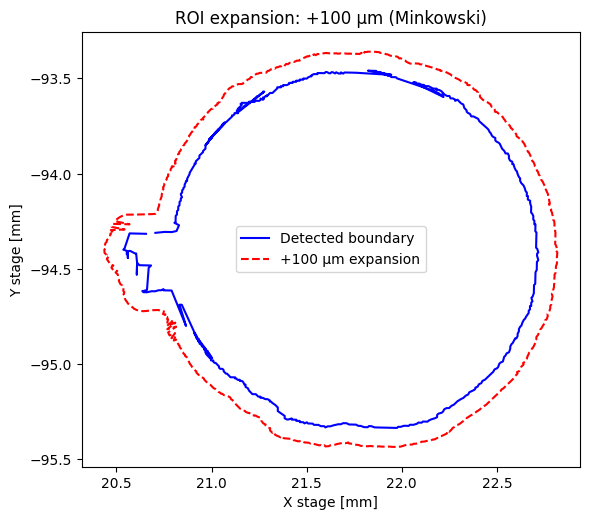

In [58]:
# Expand boundary by expansion_mm using a Minkowski-sum approximation:
#   1. Around every boundary point, sample a circle of radius expansion_mm
#   2. Pool all candidate points together
#   3. At each angle bin (from centroid), keep the outermost candidate
# This correctly handles concave features — neighbour circles 'reach around'
# indentations where a plain radial-from-centroid offset would go inward.

centroid = boundary_stage_mm.mean(axis=0)

# Step 1 — build candidate cloud (original + offset circles)
n_circle = 36   # directions per point: 360° / 36 = 10° resolution
circle_angles = np.linspace(0, 2 * np.pi, n_circle, endpoint=False)
offsets = expansion_mm * np.column_stack([np.cos(circle_angles), np.sin(circle_angles)])  # (36, 2)

# broadcast: (N_boundary, 1, 2) + (1, 36, 2) → (N_boundary, 36, 2) → (N_boundary*36, 2)
all_candidates = (boundary_stage_mm[:, None, :] + offsets[None, :, :]).reshape(-1, 2)

# Step 2 — find outermost candidate at each angle bin from centroid
cand_vec    = all_candidates - centroid
cand_angles = np.arctan2(cand_vec[:, 1], cand_vec[:, 0])
cand_radii  = np.linalg.norm(cand_vec, axis=1)

n_bins    = len(boundary_stage_mm)   # same angular resolution as input
bin_edges = np.linspace(-np.pi, np.pi, n_bins + 1)

expanded_pts = []
for i in range(n_bins):
    in_bin = (cand_angles >= bin_edges[i]) & (cand_angles < bin_edges[i + 1])
    if not in_bin.any():
        continue
    best = np.argmax(cand_radii[in_bin])
    expanded_pts.append(all_candidates[in_bin][best])

boundary_stage_mm_expanded = np.array(expanded_pts)

# Visualise
fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(boundary_stage_mm[:, 0], boundary_stage_mm[:, 1],
        'b-', lw=1.5, label='Detected boundary')
ax.plot(boundary_stage_mm_expanded[:, 0], boundary_stage_mm_expanded[:, 1],
        'r--', lw=1.5, label=f'+{expansion_mm*1e3:.0f} µm expansion')
ax.set_aspect('equal')
ax.set_xlabel('X stage [mm]'); ax.set_ylabel('Y stage [mm]')
ax.set_title(f'ROI expansion: +{expansion_mm*1e3:.0f} µm (Minkowski)')
ax.legend()
plt.tight_layout(); plt.show()

---
## Scan grid generation

In [59]:
# 1. Build closed polygon from EXPANDED boundary in stage frame
polygon = MplPath(boundary_stage_mm_expanded)

# 2. Regular grid over bounding box
x_min, x_max = boundary_stage_mm_expanded[:, 0].min(), boundary_stage_mm_expanded[:, 0].max()
y_min, y_max = boundary_stage_mm_expanded[:, 1].min(), boundary_stage_mm_expanded[:, 1].max()

xs = np.arange(x_min, x_max + step_size_mm, step_size_mm)
ys = np.arange(y_min, y_max + step_size_mm, step_size_mm)
xx, yy = np.meshgrid(xs, ys)
grid_candidates = np.column_stack([xx.ravel(), yy.ravel()])

# 3. Keep only points inside the ROI polygon
inside = polygon.contains_points(grid_candidates)
scan_pts_stage = grid_candidates[inside]   # (M, 2)  in stage frame

# 4. Stage → measurement coordinates (applies laser-position offset from calibration)
scan_pts_mea = np.array([
    img_unit.convert_stg2mea((float(x), float(y)))
    for x, y in scan_pts_stage
])  # (M, 2)

# 5. Attach Z and package
scan_coordinates = [
    (float(x), float(y), float(z_mm))
    for x, y in scan_pts_mea
]

print(
    f'Grid: {len(xs)}×{len(ys)} = {len(grid_candidates)} candidates '
    f'→ {len(scan_coordinates)} points inside expanded ROI'
)

Grid: 49×43 = 2107 candidates → 1432 points inside expanded ROI


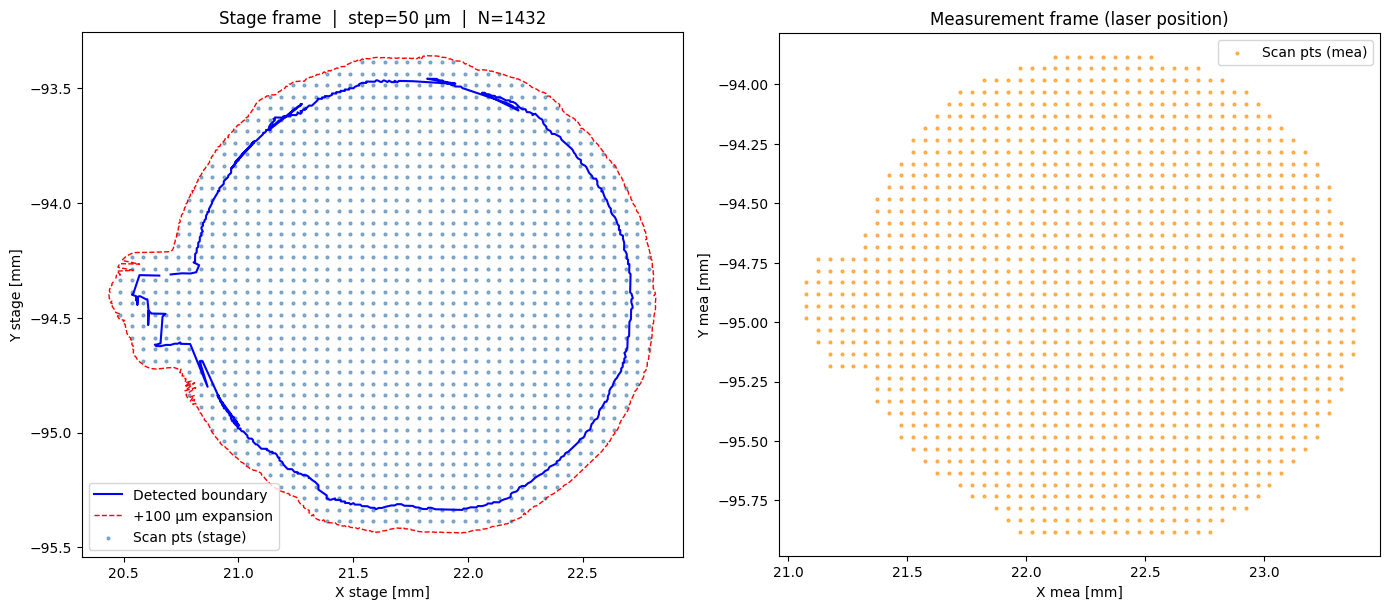

In [60]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left — stage frame with both boundaries
axes[0].plot(boundary_stage_mm[:, 0], boundary_stage_mm[:, 1],
             'b-', lw=1.5, label='Detected boundary')
axes[0].plot(boundary_stage_mm_expanded[:, 0], boundary_stage_mm_expanded[:, 1],
             'r--', lw=1, label=f'+{expansion_mm*1e3:.0f} µm expansion')
axes[0].scatter(scan_pts_stage[:, 0], scan_pts_stage[:, 1],
                s=4, c='steelblue', alpha=0.6, label='Scan pts (stage)')
axes[0].set_aspect('equal')
axes[0].set_xlabel('X stage [mm]'); axes[0].set_ylabel('Y stage [mm]')
axes[0].set_title(f'Stage frame  |  step={step_size_mm*1e3:.0f} µm  |  N={len(scan_coordinates)}')
axes[0].legend()

# Right — measurement frame (laser position)
sc_arr = np.array(scan_coordinates)
axes[1].scatter(sc_arr[:, 0], sc_arr[:, 1],
                s=4, c='darkorange', alpha=0.6, label='Scan pts (mea)')
axes[1].set_aspect('equal')
axes[1].set_xlabel('X mea [mm]'); axes[1].set_ylabel('Y mea [mm]')
axes[1].set_title('Measurement frame (laser position)')
axes[1].legend()

plt.tight_layout(); plt.show()

In [61]:
# Package as MeaCoor_mm — the format the Raman mapping system consumes
mea_coor = MeaCoor_mm(
    mappingUnit_name    = 'sers_substrate_roi',
    mapping_coordinates = scan_coordinates,
)

print(f'MeaCoor_mm "{mea_coor.mappingUnit_name}"  →  {len(mea_coor.mapping_coordinates)} coordinates')
print('First 5 (x_mea, y_mea, z) [mm]:')
for pt in mea_coor.mapping_coordinates[:5]:
    print(f'  ({pt[0]:.4f}, {pt[1]:.4f}, {pt[2]:.4f})')

MeaCoor_mm "sers_substrate_roi"  →  1432 coordinates
First 5 (x_mea, y_mea, z) [mm]:
  (21.9737, -95.8832, 0.0000)
  (22.0237, -95.8832, 0.0000)
  (22.0737, -95.8832, 0.0000)
  (22.1237, -95.8832, 0.0000)
  (22.1737, -95.8832, 0.0000)
